In [1]:
import torch
import pandas as pd
from os import PathLike
import numpy as np
import ml_confs # pip install ml-confs
import matplotlib.pyplot as plt
from tqdm import tqdm
import sklearn
import input_pipeline
import pnstyler.styler as styler # pip install git+https://github.com/pietronvll/mplstyler
plt.rcParams["figure.dpi"] = 120
device = torch.device("cuda" if torch.cuda.is_available() else "mps")

In [2]:
configs = ml_confs.from_dict({
    'data_path': '../data/map_c_100x10.txt',
    'min_shift': 1525,
    'max_shift': 1650
})

test_configs = ml_confs.from_dict({
    'data_path': '../data/Mixed_8x8.txt',
    'min_shift': 1525,
    'max_shift': 1650
})

In [14]:
data_SiC = input_pipeline.load_data(configs.data_path)
data_mixed = input_pipeline.load_data(test_configs.data_path)

In [15]:
# Normalizing counts
raw_data = input_pipeline.normalize_counts(data_SiC)
outliers, sup_norm_deviations = input_pipeline.find_outliers(raw_data["counts"])

Found 20 outliers out of 1000 spectra


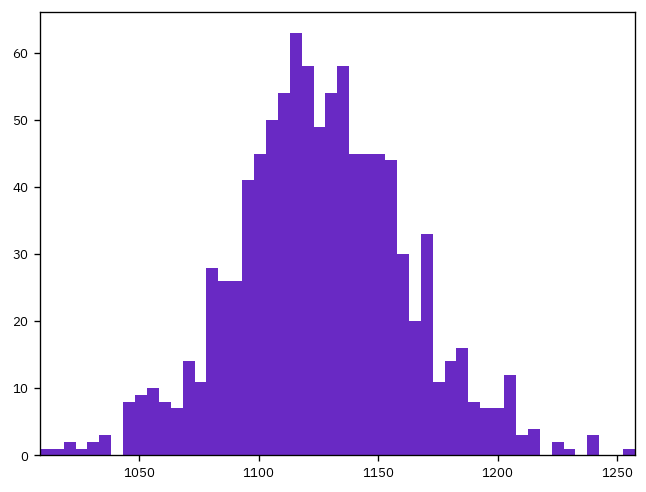

In [26]:
plt.hist(data_SiC['counts'][~outliers].max(axis=1).values, bins = 50);

(-10.0, 2000.0)

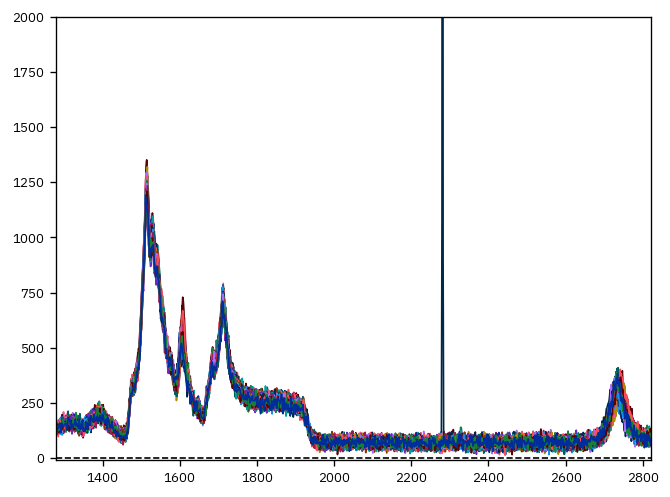

In [30]:
for i in range(64):
    plt.plot(data_mixed["raman_shift"][i], data_mixed["counts"][i])
    #plt.plot(data_mixed["raman_shift"][i], data_mixed["counts"][i])
plt.axhline(0, color='black', linestyle='--')
#plt.xlim(1400, 1800)
plt.ylim(-10, 2e3)

In [5]:
ds = input_pipeline.RamanSpectraDataset(configs, train_ratio = 0.9)
train_ds = ds.get_split('train')
val_ds = ds.get_split('val')
test_ds = input_pipeline.RamanSpectraDataset(test_configs, train_ratio = 1.0).get_split('train')

Found 20 outliers out of 1000 spectra
Found 2 outliers out of 64 spectra


/home/novelli/anaconda3/envs/kooplearn/lib/python3.11/site-packages/torch/utils/data/dataset.py:348: UserWarning: Length of split at index 1 is 0. This might result in an empty dataset.
  warnings.warn(f"Length of split at index {i} is 0. "


In [9]:
max_dist = [x['counts'].max() for x in train_ds]

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0., 883.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([1.        , 1.00999999, 1.01999998, 1.02999997, 1.03999996,
        1.04999995, 1.05999994, 1.07000005, 1.08000004, 1.09000003,
        1.10000002, 1.11000001, 1.12      , 1.13      , 1.13999999,
        1.14999998, 1.15999997, 1.16999996, 1.17999995, 1.19000006,
        1.20000005, 1.21000004, 1.22000003, 1.

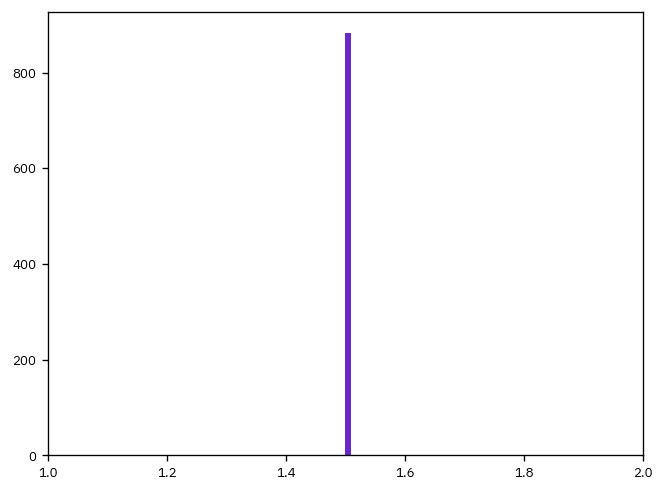

In [7]:
class SpectraFormer(torch.nn.Module):
    def __init__(
        self,
        input_dim: int = 2,
        dim_feedforward: int = 128,
        embedding_dim: int = 32,
        num_heads: int = 2,
        num_layers: int = 2,
    ):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.num_layers = num_layers

        self.embedding = torch.nn.Linear(input_dim, embedding_dim)
        self.transformer = torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(
                d_model=embedding_dim,
                dim_feedforward=dim_feedforward,
                nhead=num_heads,
                batch_first=True,
            ),
            num_layers=num_layers,
        )
        self.activation = torch.nn.ReLU()
        self.lin_final = torch.nn.Linear(embedding_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        x = self.activation(x)
        x = self.lin_final(x).squeeze(-1)
        x = self.activation(x)
        return x

In [25]:
max_epochs = 50
model = SpectraFormer()
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

train_dl = torch.utils.data.DataLoader(train_ds, batch_size = 100)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size = 100)

masked_loss_outweight = 100

train_losses = []
val_losses = [np.nan]
val_steps = []
step = 0

In [26]:
def _normalize_shift(shift: torch.tensor):
    return (shift - 1200)/800

In [27]:
# Training loop
for epoch in range(max_epochs):
    model.train()
    train_pbar = tqdm(train_dl, desc=f"Epoch {epoch + 1}/{max_epochs}", leave=False)
    for batch in train_pbar:
        optimizer.zero_grad()
        x = torch.stack([_normalize_shift(batch['raman_shift']), batch['masked_counts']], dim=-1)
        x = x.to(device)
        pred = model(x)
        loss = (pred - batch['counts'].to(device))**2
        #loss = torch.where(batch['masked'].to(device), loss, loss*(masked_loss_outweight**-1.))
        loss = loss.mean()
        loss.backward()
        optimizer.step()
        train_pbar.set_description(f"Epoch {epoch + 1}/{max_epochs} - Loss: {loss.item():.5f} - Val loss: {val_losses[-1]:.5f}")
        train_losses.append(loss.item())
        step = step + 1
    model.eval()
    val_loss = 0
    for batch in val_dl:
        with torch.no_grad():
            x = torch.stack([_normalize_shift(batch['raman_shift']), batch['masked_counts']], dim=-1)
            x = x.to(device)
            pred = model(x)
            loss = (pred - batch['counts'].to(device))**2
            #loss = torch.where(batch['masked'].to(device), loss, loss*(masked_loss_outweight**-1.))
            loss = loss.mean()
            val_loss += loss.item()
    val_losses.append(val_loss/len(val_dl))
    val_steps.append(step)

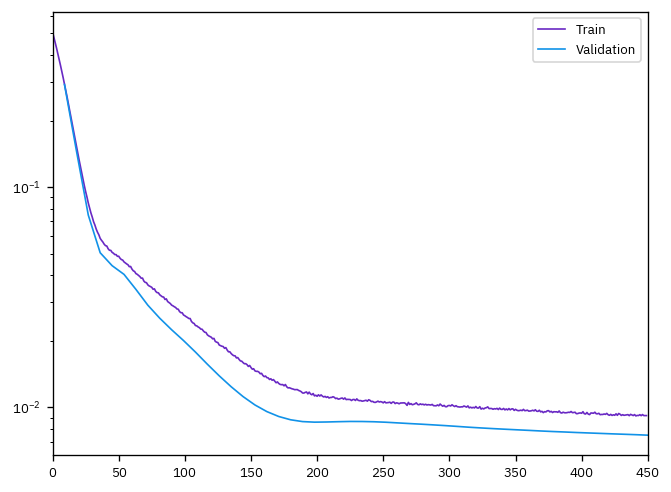

In [28]:
plt.plot(train_losses, label ='Train')
plt.plot(val_steps, val_losses[1:], label = 'Validation')
plt.legend()
plt.yscale('log')

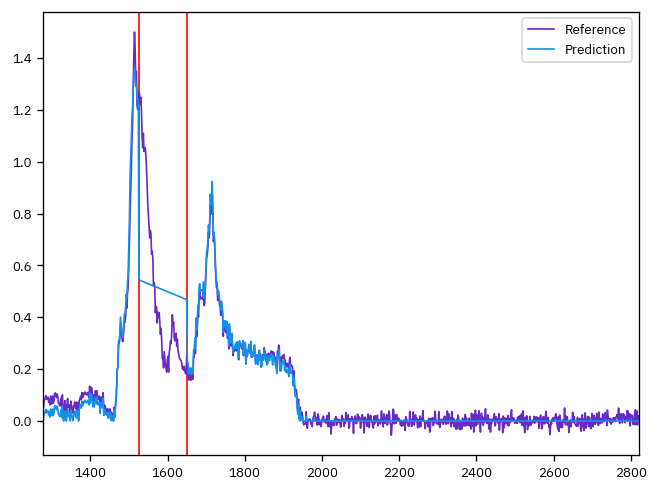

In [29]:
with torch.no_grad():
    model.eval()
    batch = val_ds[0]
    x = torch.stack([_normalize_shift(batch['raman_shift']), batch['masked_counts']], dim=-1)
    x = x.to(device)
    pred = model(x)
    pred = pred.cpu().numpy()
    plt.axvline(configs.min_shift, color='r')
    plt.axvline(configs.max_shift, color='r')
    plt.plot(batch['raman_shift'], batch['counts'], label='Reference')
    plt.plot(batch['raman_shift'], pred, label='Prediction')
    plt.legend()

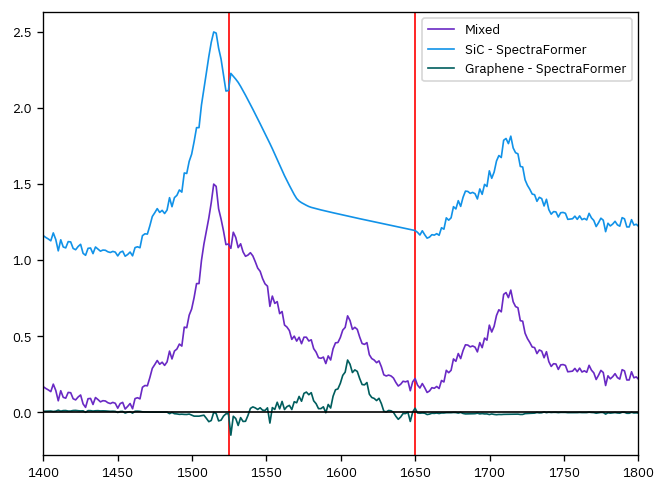

In [22]:
with torch.no_grad():
    model.eval()
    batch = test_ds[1]
    x = torch.stack([_normalize_shift(batch['raman_shift']), batch['masked_counts']], dim=-1)
    x = x.to(device)
    pred = model(x)
    pred = pred.cpu().numpy()
    plt.axvline(configs.min_shift, color='r')
    plt.axvline(configs.max_shift, color='r')
    plt.plot(batch['raman_shift'], batch['counts'], label='Mixed')
    plt.plot(batch['raman_shift'], pred +1, label='SiC - SpectraFormer')
    plt.plot(batch['raman_shift'], batch['counts'] - pred, label='Graphene - SpectraFormer')
    plt.xlim(1400, 1800)
    plt.axhline(0, color='k')
    plt.legend()

In [51]:
torch.save(model.state_dict(), 'model.pt')